# **Data Storytelling: Thailand Fisheries Import-Export**

**Context**

ประเทศไทยเป็นหนึ่งในผู้เล่นสำคัญในอุตสาหกรรมประมงและอาหารทะเลระดับโลก ข้อมูลชุดนี้คือสถิติการนำเข้าและส่งออกสินค้าประมงของไทยตลอดปี 2568 (พ.ศ.) รวบรวมจาก [Government Open Data](https://data.go.th/dataset/impexp_product) การทำความเข้าใจโครงสร้างการค้าประมง ไม่เพียงแต่ช่วยสะท้อนศักยภาพของไทยในฐานะ "ครัวของโลก" แต่ยังช่วยชี้ให้เห็นถึงความท้าทายในการจัดหาวัตถุดิบ และโอกาสในตลาดส่งออก

**Objectives**
1. Major Trading Partners
2. Fisheries Product Structure
3. Seasonal Trade Patterns

---
## **Prepare Data**

In [2]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#set font Thai
plt.rcParams['font.family'] = 'Tahoma' 
plt.rcParams['axes.unicode_minus'] = False 
sns.set_theme(style="whitegrid", rc={"font.family": "Tahoma"})

In [3]:
# Load data
df = pd.read_csv('data.csv')

---
## **Explore and Analysis Data**

In [4]:
df.head()

,year,month,heading11,countryID,countryNameTH,weight,quantity,price,tradeflow,productDetailEN,productDetailTH,ETL_DATE
0,2568,8,1062000002,BJ,เบนิน,33,90,48080,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
1,2568,8,1062000002,MU,มอริเชียส,10,50,44147,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
2,2568,8,1062000002,BR,บราซิล,8,150,47068,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
3,2568,8,1062000002,EG,อียิปต์,315,100,225663,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59
4,2568,9,1062000002,KE,เคนยา,49,200,74954,1,Turtles and snapping turtles live,เต่าและตะพาบน้ำมีชีวิต,12/3/2026 5:59


In [5]:
print(df.shape)
print(df.info())

(42057, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42057 entries, 0 to 42056
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   year             42057 non-null  int64 
 1   month            42057 non-null  int64 
 2   heading11        42057 non-null  int64 
 3   countryID        42032 non-null  object
 4   countryNameTH    42057 non-null  object
 5   weight           42057 non-null  int64 
 6   quantity         42057 non-null  int64 
 7   price            42057 non-null  int64 
 8   tradeflow        42057 non-null  int64 
 9   productDetailEN  42057 non-null  object
 10  productDetailTH  42057 non-null  object
 11  ETL_DATE         42057 non-null  object
dtypes: int64(7), object(5)
memory usage: 3.9+ MB
None


In [6]:
# Data Quality Check
print("Data Quality Check")
print(f"Total Records: {len(df)}")
print(f"Duplicate Rows: {df.duplicated().sum()}")

print(f"Missing Values:")
print(df.isnull().sum())

Data Quality Check
Total Records: 42057
Duplicate Rows: 5
Missing Values:
year                0
month               0
heading11           0
countryID          25
countryNameTH       0
weight              0
quantity            0
price               0
tradeflow           0
productDetailEN     0
productDetailTH     0
ETL_DATE            0
dtype: int64


In [7]:
# Additional Checks and Transformations
# Tradeflow mapping 1 = Export, 2 = Import
df['tradeflow_label'] = df['tradeflow'].map({1: 'Export', 2: 'Import'})

# Calculate Trade Balance logic per transaction
df['trade_value_thb'] = df['price']

In [8]:
# KPI & Distribution
kpi_total_export = df[df['tradeflow_label']=='Export']['price'].sum()
kpi_total_import = df[df['tradeflow_label']=='Import']['price'].sum()
trade_balance = kpi_total_export - kpi_total_import

print("Key Performance Indicators (KPI)")
print(f"Total Export Value: {kpi_total_export:,.2f} THB")
print(f"Total Import Value: {kpi_total_import:,.2f} THB")
print(f"Trade Balance: {trade_balance:,.2f} THB (" + ("Surplus" if trade_balance > 0 else "Deficit") + ")")

Key Performance Indicators (KPI)
Total Export Value: 152,449,613,596.00 THB
Total Import Value: 223,123,001,243.00 THB
Trade Balance: -70,673,387,647.00 THB (Deficit)


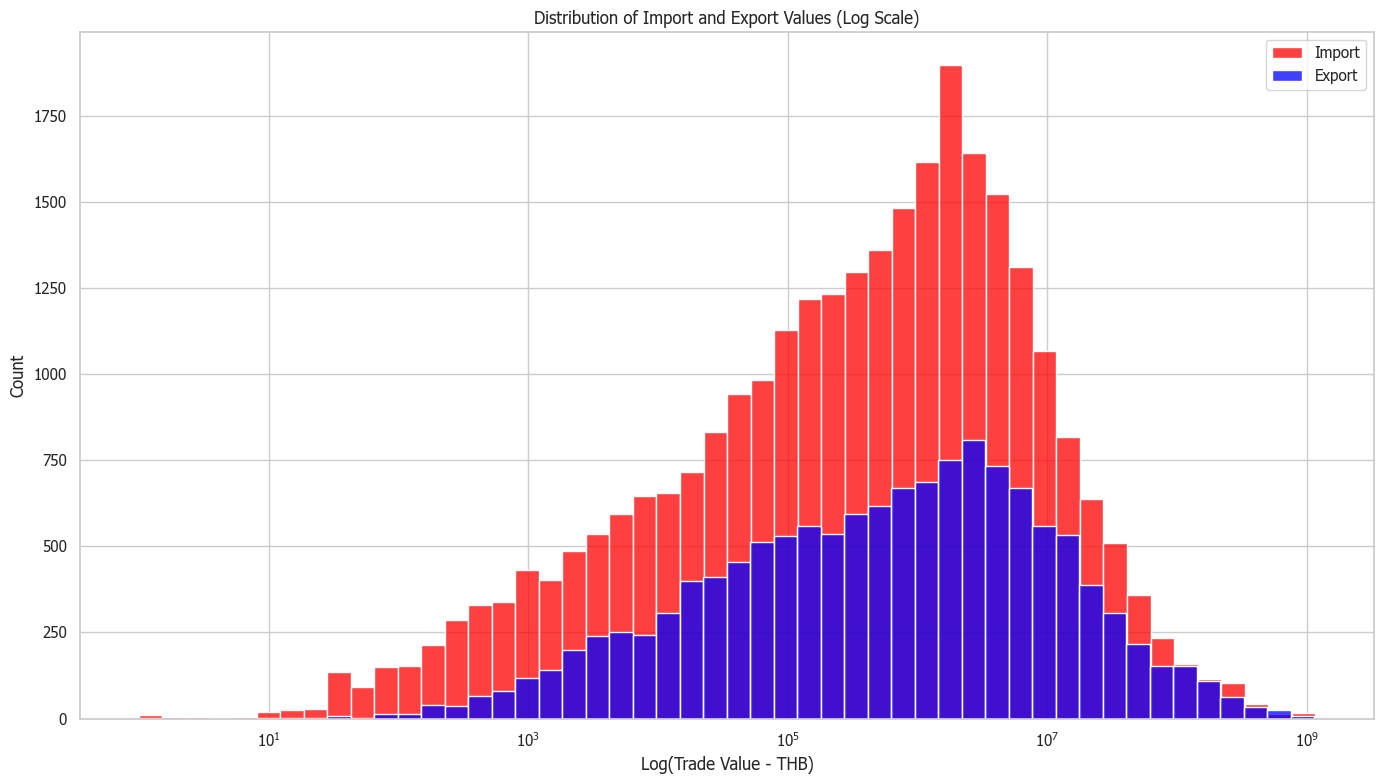

In [23]:
# Distribution of Trade Values
import gc
plt.figure(figsize=(14, 8))

plt.subplot(1, 1, 1)
sns.histplot(df[df['tradeflow_label']=='Import']['price'], bins=50, color='red', log_scale=True, label='Import')
sns.histplot(df[df['tradeflow_label']=='Export']['price'], bins=50, color='blue', log_scale=True, label='Export')
plt.title('Distribution of Import and Export Values (Log Scale)')
plt.xlabel('Log(Trade Value - THB)')

plt.tight_layout()
plt.legend()
plt.show()

**EDA Insights & Next Questions:**
- Macro KPI ชี้ชัดว่าประเทศไทยมี **การขาดดุล**
- Log-normal distribution แสดงว่าพฤติกรรมการมีธุรกรรมย่อยๆ เป็นฐานรากมหาศาล และมี Transactions ทุนใหญ่ระดับพันล้าน ในช่วง Right tail
> **Next Question:** การเกินดุลเหล่านั้นมาจากเราขายของให้ใคร? และเราต้องจ่ายเงินซื้อของแพงๆ กับใครล่ะ?

---
## **Q1: Major Trading Partners**
**โจทย์:** ประเทศใดเป็นตลาดส่งออก/แหล่งนำเข้าหลัก และประเทศใดที่ไทยเกินดุลหรือขาดดุลอย่างชัดเจน

In [10]:
# Aggregate by Country
country_trade = df.groupby(['countryNameTH', 'tradeflow_label'])['price'].sum().unstack(fill_value=0)
country_trade['Balance'] = country_trade.get('Export', 0) - country_trade.get('Import', 0)
country_trade['Total_Trade'] = country_trade.get('Export', 0) + country_trade.get('Import', 0)

# Sort for plotting top 15 by Total Trade
top_countries = country_trade.sort_values(by='Total_Trade', ascending=False).head(15)

print("Complete.")

Complete.


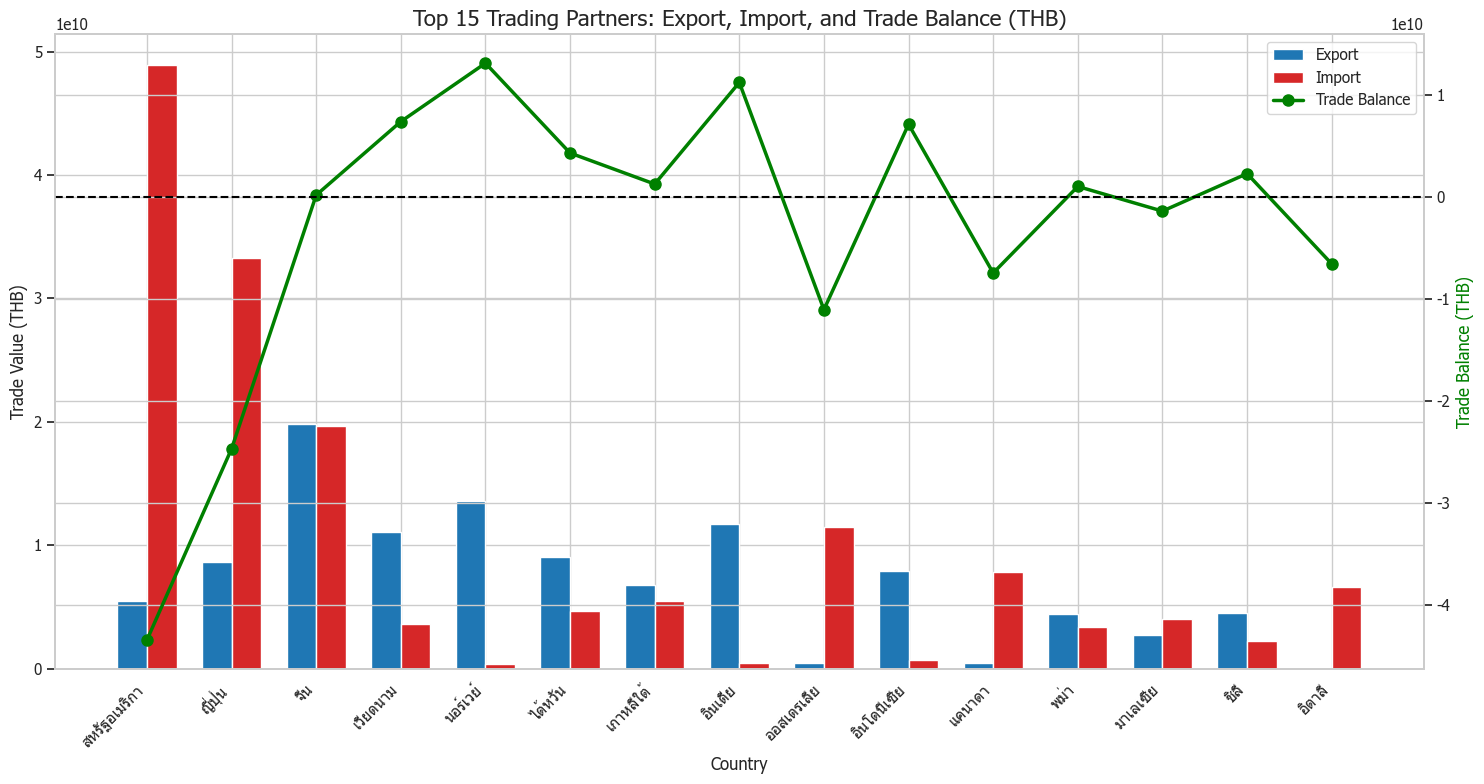

In [11]:
plt.figure(figsize=(15, 8))
bar_width = 0.35
indices = np.arange(len(top_countries))

ax1 = plt.gca()

# Plot Export (Blue) and Import (Red)
ax1.bar(indices - bar_width/2, top_countries['Export'], width=bar_width, color='#1f77b4', label='Export')
ax1.bar(indices + bar_width/2, top_countries['Import'], width=bar_width, color='#d62728', label='Import')

# Trade Balance on secondary Y-axis
ax2 = ax1.twinx()
ax2.plot(indices, top_countries['Balance'], color='green', marker='o', markersize=8, linewidth=2.5, label='Trade Balance')
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_ylabel('Trade Balance (THB)', color='green', fontsize=12)

# Label
ax1.set_xticks(indices)
ax1.set_xticklabels(top_countries.index, rotation=45, ha='right', fontsize=11)
ax1.set_title('Top 15 Trading Partners: Export, Import, and Trade Balance (THB)', fontsize=16)
ax1.set_xlabel('Country', fontsize=12)
ax1.set_ylabel('Trade Value (THB)', fontsize=12)

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

**Insight & Analysis (What & Why):**
- **What:** ตลาดส่งออกหลักอันดับต้นๆ คือ สหรัฐอเมริกา และ ญี่ปุ่น (แท่งสีฟ้านำโด่ง และเส้นกราฟสีเขียวสูงสะท้อนยอด Surplusเกินดุลการค้ามหาศาล) ขณะที่แหล่งนำเข้าหลักของเราคือ ไต้หวัน จีน และเกาะแถบมหาสมุทร (ขาดดุล / แท่งแดงนำเส้นเขียวดิ่งลงใต้ศูนย์)
- **Why:** สหรัฐฯ และญี่ปุ่นเป็นประเทศพัฒนาแล้วที่มีกำลังซื้อสูง แต่กลับมีความต้องการบริโภคอาหารทะเลแปรรูป มหาศาล ในขณะเดียวกัน ประเทศไทยมีน่านน้ำไม่พอและจับปลาทูน่าขั้นต้นได้จำกัด เราจึงกลายเป็นลูกค้า VIP ที่ต้องนำเข้าวัตถุดิบ ปลาแช่แข็ง จากไต้หวันและหมู่เกาะเพื่อเอามา **"เข้าโรงงานแปรรูป"** ก่อนส่งออกทำกำไร

**เหตุผลที่เลือกใช้กราฟนี้:** 
การใช้ **Grouped Bar Chart ซ้อนกับ Line Chart (Dual-Axis)** สามารถรวมเล่าข้อมูลได้ 3 มิติในกราฟเดียว (Export, Import, และ Balance) ช่วยให้ผู้ชมแยกมวลรวมปริมาณซื้อ-ขายออกจาก "กำไรสุทธิการค้า" ได้ในเสี้ยววินาที ไม่ต้องแบ่งกราฟหลายตัวให้สับสนความเชื่อมโยง

---
## **Q2: Fisheries Product Structure**
**โจทย์:** สินค้าประเภทใดที่ส่งออกมากกว่านำเข้า (Net Export) และใดที่พึ่งพาการนำเข้า (Net Import)

In [12]:
# Aggregating by Product
product_trade = df.groupby(['heading11', 'tradeflow_label'])['price'].sum().unstack(fill_value=0)
product_trade['Net_Export'] = product_trade.get('Export', 0) - product_trade.get('Import', 0)
product_trade['Total_Volume'] = product_trade.get('Export', 0) + product_trade.get('Import', 0)

# Select Top 20 by absolute trade influence
top_products = product_trade.sort_values(by='Total_Volume', ascending=False).head(20)

# Resort for diverging visualization (from most deficit to most surplus)
top_products = top_products.sort_values(by='Net_Export', ascending=True)

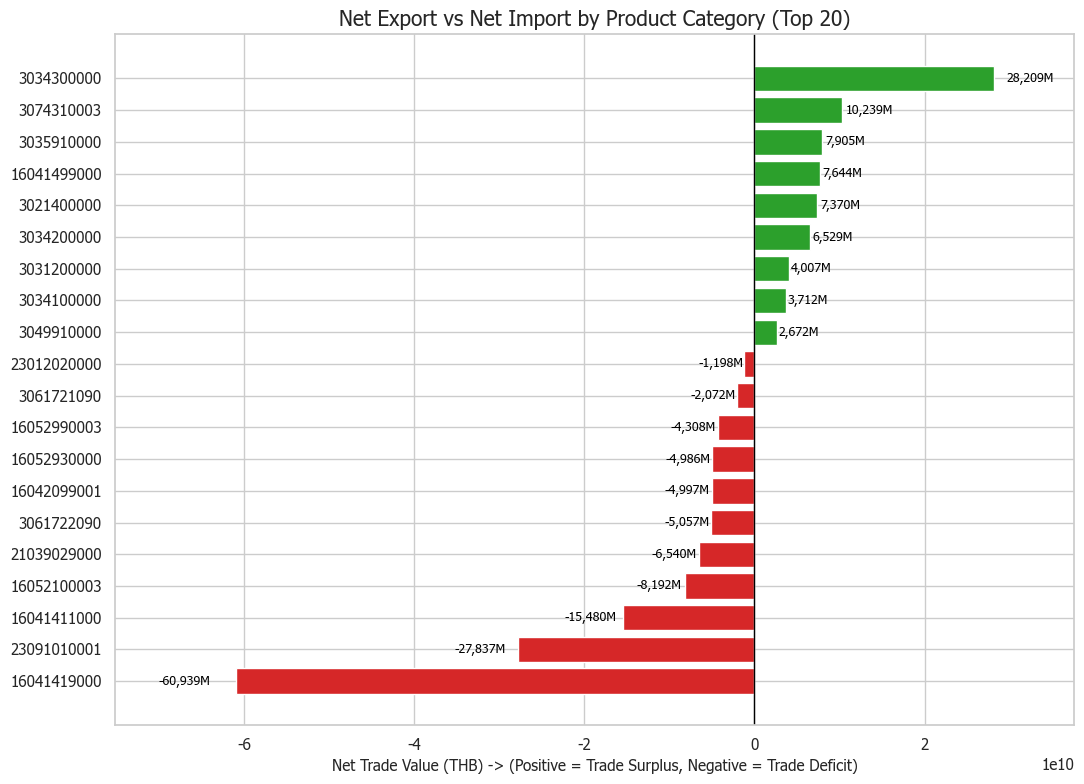

In [13]:
plt.figure(figsize=(11, 8))
colors = ['#2ca02c' if val > 0 else '#d62728' for val in top_products['Net_Export']]

bars = plt.barh(top_products.index.astype(str), top_products['Net_Export'], color=colors)
plt.axvline(0, color='black', linewidth=1)

plt.title('Net Export vs Net Import by Product Category (Top 20)', fontsize=15)
plt.xlabel('Net Trade Value (THB) -> (Positive = Trade Surplus, Negative = Trade Deficit)', fontsize=11)

# Value annotations on bars
for bar in bars:
    width = bar.get_width()
    label_x_pos = width + (width*0.05) if width > 0 else width + (width*0.05)
    align = 'left' if width > 0 else 'right'
    plt.text(label_x_pos, bar.get_y() + bar.get_height()/2, f'{width/1e6:,.0f}M', 
             va='center', ha=align, color='black', fontsize=9)

xmin, xmax = plt.xlim()
plt.xlim(xmin * 1.15, xmax * 1.15)

plt.tight_layout()
plt.show()

**Insight & Analysis (What & Why):**
- **What:** ไทยคือมหาอำนาจการประมงสายชุบแป้งทอดและกระป๋อง เรามียอด Net Export ติดโซนสีเขียวในกลุ่ม "สินค้าแปรรูปมูลค่าเพิ่ม" (เช่น กุ้งแช่แข็งเบอร์ต่างๆ, สัตว์น้ำแปรรูป) แต่เราหัวร่วงตกมาอยู่โซนสีแดง (Net Import) ใน "ปลาแช่แข็งตัวใหญ่ๆ" เช่น ทูน่า, แซลมอน
- **Why:** ศักยภาพหลักของ Value Chain ประมงไทยคือ **"กรรมวิธีการผลิตและโรงงานแปรรูป"** ที่ล้ำสมัยระดับโลก ทิ้งห่างประเทศคู่แข่ง เราไม่ได้มีทัพเรือรบประมงมากมายที่ไปจับปลาได้ทั่วทะเลลึก แต่เรามีโรงงานที่รับวัตถุดิบดิบจากไต้หวันและอินเดีย แล้วใช้ Value-add (ความรู้ + แรงงานมีทักษะ) เสกมันให้แพงขึ้นก่อนส่งออกขายฝรั่ง

**เหตุผลที่เลือกใช้กราฟนี้:** 
โครงสร้าง **Diverging Bar Chart (กราฟแท่งแนวนอนแบบแยกซ้ายขวา)** ตอบโจทย์สมบูรณ์แบบที่สุดสำหรับการอธิบาย Concept ของ Net Export/Import ที่มี Center line ศูนย์กลางให้เห็นขั้ว 2 ฝั่งชัดเจน (สีเขียวคือหาเงินเข้า สีแดงคือจ่ายเงินออก)

---
## **Q3: Seasonal Trade Pattern**
**โจทย์:** แนวโน้มการนำเข้า-ส่งออก รายเดือน Peak และ Low อยู่ช่วงไหน เกิดจากปัจจัยใด?

In [14]:
def peak_low(col):
    # Find Peaks and Lows
    peak_ex = monthly_trade[col].idxmax()
    low_ex = monthly_trade[col].idxmin()

    # Annotate Peak
    plt.annotate(f'Peak {col}\n(Month {peak_ex})', 
                xy=(peak_ex, monthly_trade.loc[peak_ex, col]), 
                xytext=(peak_ex, monthly_trade.loc[peak_ex, col] * 1.08),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), 
                ha='center', fontsize=10, weight='bold', color='darkblue')

    # Annotate Low
    plt.annotate(f'Low {col}\n(Month {low_ex})', 
                xy=(low_ex, monthly_trade.loc[low_ex, col]), 
                xytext=(low_ex, monthly_trade.loc[low_ex, col] * 0.90),
                arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8), 
                ha='center', fontsize=10, weight='bold', color='darkred')

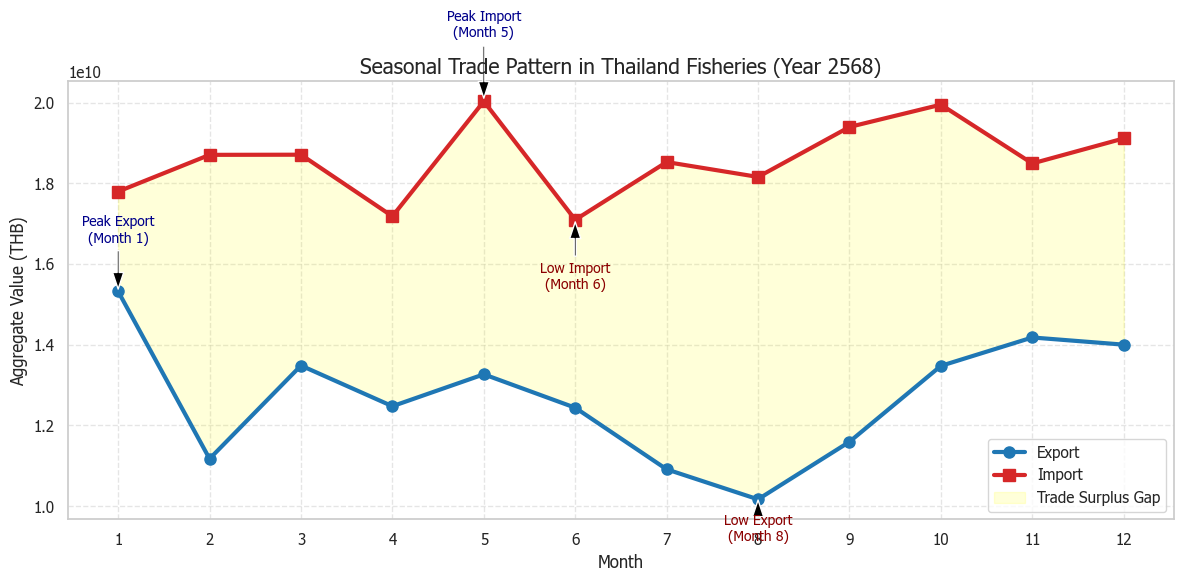

In [15]:
monthly_trade = df.groupby(['month', 'tradeflow_label'])['price'].sum().unstack(fill_value=0)

plt.figure(figsize=(12, 6))

# Plot lines
plt.plot(monthly_trade.index, monthly_trade['Export'], marker='o', linewidth=3, 
         color='#1f77b4', markersize=8, label='Export')
plt.plot(monthly_trade.index, monthly_trade['Import'], marker='s', linewidth=3, 
         color='#d62728', markersize=8, label='Import')

# Fill area between to represent Trade Gap
plt.fill_between(monthly_trade.index, monthly_trade['Import'], monthly_trade['Export'], 
                 color='yellow', alpha=0.15, label='Trade Surplus Gap')

peak_low('Export')
peak_low('Import')

plt.title('Seasonal Trade Pattern in Thailand Fisheries (Year 2568)', fontsize=15, weight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Aggregate Value (THB)', fontsize=12)
plt.xticks(np.arange(1, 13, 1))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

**Insight & Analysis (What & Why):**
- **What:** Time-series บ่งชี้ว่า ช่วง Peak สะสมตัวอยู่ในช่วง เดือนแรก ช่วง Low อยู่ในช่วงไตรมาศ 2 และจุดต่ำสุดในเดือน 8
- **Hypothesis (Why?):** 
  1. **เทศกาลบริโภคระดับโลก:** ช่วงปลายปี ซีกโลกตะวันตกมีเทศกาลใหญ่ติดกัน (Thanksgiving & Christmas) คำสั่งซื้อจึงทะลักมายังประเทศไทยโรงงานต้องเดินเครื่องรอบจัด ส่งมอบลงเรือล่วงหน้าตั้งแต่เดือนสิงหาคม-ตุลาคม
  2. **ฤดูมรสุมและพักท้องทะเล:** ช่วงต้นปีถึงกลางปีบ้านเรามีหน้ามรสุมและมาตรการปิดอ่าว (หยุดจับปลา) Supply ของปลาสดหายาก โรงงานต้องอาศัยการสะสม Stock (จะเห็นว่า Import ค่อนข้างนิ่งเป็นเส้นราบเพื่อรักษาฐานวัตถุดิบเสมอ)

**เหตุผลที่เลือกใช้กราฟนี้:**
**Line Chart (กราฟเส้นประชันกัน)** ถือเป็น Standard Gold สำหรับอ่านค่า Trend เวลา เสริมฟังก์ชันด้วยการถมสีแทรกกลาง **(Fill Area)** เพื่อเน้นย้ำถึงส่วนต่างที่สร้างกระแสเงินสดให้เข้าประเทศ (Trade Gap Margin) ทริคนี้จะชูโรงเล่าเรื่องให้เห็นความอุดมสมบูรณ์ของรายได้เรา

---
## **Insight**

### Actionable Insight

**บทสรุปภูมิรัฐศาสตร์การประมงไทย:**
การวิเคราะห์ทำให้เราทะลวงไปเห็นแก่นกระดูกดำว่า ประเทศไทยคือ **"สุดยอดพ่อครัวประมงของโลก"** ศักยภาพเราโกยเงินเข้าให้ตัวเลข Net Export ทะยานสูงเสียดฟ้าในกลุ่ม "ผลิตภัณฑ์แปรรูป" กราฟ Q2 กินผลกำไรจากเศรษฐีอย่างสหรัฐอเมริกา กราฟ Q1 แต่จุดเปราะบางของเราคือ เราเป็น **"ผู้แบกรับความเสี่ยงวัตถุดิบ"** เราต้องง้อแหล่งประมงขั้นต้นต่างชาติมหาศาลเพื่อเติมของในโรงงาน 

### Actionable Recommendations
1. **เสริมเกราะห่วงโซ่อุปทาน:** ภาครัฐต้องทำ MOU G2G หรือสัญญาระยะยาวจองโควต้าแหล่งทูน่ากับประเทศเกาะ/เพื่อนบ้าน เพื่อป้องกัน "ช็อคสต็อก" หากเกิดสงครามการค้าหรือวิกฤตขนส่ง
2. **ฉีกกรอบสินค้าพรีเมียม:** ห้ามเอาปลาไทยไปแข่งกับเวียดนามด้วย "ราคา" ทิศทางต่อไปคือการยกระดับสู่ Food Tech, อาหารแห่งอนาคต, อาหารการแพทย์, อาหารกัญชง เพื่อดัน Margin ขั้นสุดยอด
3. **ยุทธศาสตร์คลังสินค้า:** โลจิสติกส์ต้องแม่นยำ จาก Q3 Seasonality บริษัทเดินเรือและห้องเย็น ต้องเตรียม Warehouse รอกอบโกยออเดอร์ให้พร้อม 2 เดือนล่วงหน้าก่อนเข้า Peak ระหว่างไตรมาส 3

---
##(Bonus) Draft Video Script Data Storytelling (Pitching 1 นาที ⏱️)

**(0:00 - 0:15) Context:**
"คุณคิดว่าประมงไทยแข็งแกร่งแค่ไหนครับ? ...จาก Open Data สถิติการค้าทั้งตลอดปี มันได้เปิดเผยความลับบางอย่างที่เราอาจเข้าใจผิดมาตลอด!"

**(0:15 - 0:40) Insight:**
"ดูที่กราฟนี้นะครับ (ชี้กราฟ 1): สหรัฐและญี่ปุ่น จ่ายเงินซื้อของจากเราเยอะที่สุดจนเราได้ดุลมหาศาล! แต่เดี๋ยวก่อน! ถ้าดูดีๆ ในกราฟที่ 2 (ชี้กราฟ 2) เราดิ่งติดลบกับการนำเข้าวัตถุดิบอย่างทูน่าแช่แข็ง นั่นแปลว่า... เราไม่ใช่กัปตันหาปลาที่เจ๋งที่สุด แต่เราคือ **'กุ๊ก(Chef)'** ที่แปรรูปเก่งที่สุดต่างหาก! และเราจะงานหนักทะลุเพดานแบบสุดๆ ในช่วงไตรมาส 3 (ชี้กราฟ 3) เพื่อเสกของส่งให้ทันเทศกาลคริสต์มาสของฝรั่ง!"

**(0:40 - 1:00) So What:**
"ทีนี้ So What!?... สิ่งที่อันตรายที่สุดคือ 'ถ้าต้นน้ำแบนเรา โรงงานเราจะตายทันที' ทางรอดของประมงไทยคือ... ภาครัฐต้องเร่งล็อกสัมปทานนำเข้าวัตถุดิบระยะยาว และเอกชนต้องยกระดับสินค้าหนีสงครามราคาไปสู่ Premium Seafood ระดับโลก... หมดเวลาขายแรงงานแล้วครับ ประเทศไทยต้องขายสติปัญญา... ขอบคุณครับ!"